# Fase 8 — Walk-forward validation

Si addestra un modello nuovo per ogni fold, si seleziona il checkpoint sulla sola validation e si valuta nella finestra successiva. Le equity OOS vengono concatenate con capitale continuo. Il risultato va letto insieme ai contributi dei singoli fold e alle baseline.

Il holdout finale resta escluso da questa fase. Questi fold sono retrospettivi: parte dei periodi era già stata osservata in Fase 7. Inoltre la Fase 7 non ha superato il criterio multi-seed; usare un seed fisso per fold isola la variabilità temporale, non risolve quella sensibilità.


In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Markdown, Image
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "config.yaml").exists() and (p / "scripts/train_walk_forward.py").exists())
RUN_ID = "phase8_initial_20260930"
REPORT_DIR = ROOT / "reports/walk_forward" / RUN_ID
manifest = json.loads((REPORT_DIR / "manifest.json").read_text(encoding="utf-8"))
summary = json.loads((REPORT_DIR / "summary.json").read_text(encoding="utf-8"))
metrics = pd.read_csv(REPORT_DIR / "walk_forward_metrics.csv")
equity = pd.read_csv(REPORT_DIR / "walk_forward_equity.csv", parse_dates=["timestamp"])
assert summary["run_id"] == manifest["run_id"] == RUN_ID
assert summary["holdout_used"] is False
assert equity["timestamp"].max() < pd.Timestamp(manifest["holdout_start"])
display(Markdown(f"**Esperimento:** `{RUN_ID}`. **Holdout escluso dal:** {manifest['holdout_start']}."))


**Esperimento:** `phase8_initial_20260930`. **Holdout escluso dal:** 2023-05-30 11:30:00.

## Finestre, scaler e selezione

Ogni fold usa 5 anni di training, 6 mesi di validation e i successivi 6 mesi di test. Le date sono limiti inclusivi a sinistra ed esclusivi a destra. Lo scaler è stimato solo sul training del fold. Una barra precedente a validation/test fornisce il contesto per la prima decisione; non viene conteggiata nelle performance della finestra.

Ogni modello parte da zero. I checkpoint periodici e il modello dopo l'ultimo aggiornamento vengono valutati sulla validation. Vince il rendimento composto maggiore dopo la liquidazione; a parità vince il primo candidato. Il test non è passato al callback di selezione. I test passati possono entrare nel training/validation dei fold successivi, perché a quel punto appartengono alla storia disponibile.


In [2]:
fold_table = pd.DataFrame([{k:v for k,v in fold.items() if k != "normalization"} for fold in manifest["folds"]])
display(fold_table)
display(pd.DataFrame(summary["models"])[["fold", "seed", "actual_timesteps", "selected_timesteps", "selected_stage", "validation_return", "native_reload_verified"]])
selection_rows = []
for model in summary["models"]:
    folder = ROOT / "models/walk_forward" / RUN_ID / f"fold_{model['fold']}"
    candidates = pd.read_csv(folder / "validation_scores.csv")
    assert abs(candidates["total_return"].max() - model["validation_return"]) < 1e-12
    selection_rows.append({"fold": model["fold"], "candidati valutati": len(candidates), "test usato": model["test_used"]})
display(pd.DataFrame(selection_rows))


,number,train_start,validation_start,test_start,test_end,train_rows,validation_rows,test_rows
0,1,2015-11-30 11:30:00,2020-11-30 11:30:00,2021-05-30 11:30:00,2021-11-30 11:30:00,114578,11320,11701
1,2,2016-05-30 11:30:00,2021-05-30 11:30:00,2021-11-30 11:30:00,2022-05-30 11:30:00,114718,11701,11355
2,3,2016-11-30 11:30:00,2021-11-30 11:30:00,2022-05-30 11:30:00,2022-11-30 11:30:00,114718,11355,11765
3,4,2017-05-30 11:30:00,2022-05-30 11:30:00,2022-11-30 11:30:00,2023-05-30 11:30:00,114831,11765,11312


,fold,seed,actual_timesteps,selected_timesteps,selected_stage,validation_return,native_reload_verified
0,1,42,251904,225000,periodic,-0.047836,True
1,2,42,251904,75000,periodic,-0.025878,True
2,3,42,251904,225000,periodic,-0.034612,True
3,4,42,251904,251904,final,-0.052444,True


,fold,candidati valutati,test usato
0,1,11,False
1,2,11,False
2,3,11,False
3,4,11,False


## Equity OOS e baseline

PPO è confrontato con always_flat, always_long, random, momentum a un passo ed EMA 12/26. Le regole sono fissate prima del test. I segnali usano esclusivamente informazioni precedenti all'esecuzione e lo stesso motore di costi e portafoglio.

Ogni strategia parte con 100.000 e conserva il proprio saldo tra i fold. Si liquida all'ultimo close di ogni finestra, pagando i costi. Non si effettuano reset gratuiti o ribasamenti: il motore usa quantità fisse di una unità, e le osservazioni PPO includono lo stato del portafoglio sul capitale effettivo. I rendimenti del CSV includono i passaggi di confine.


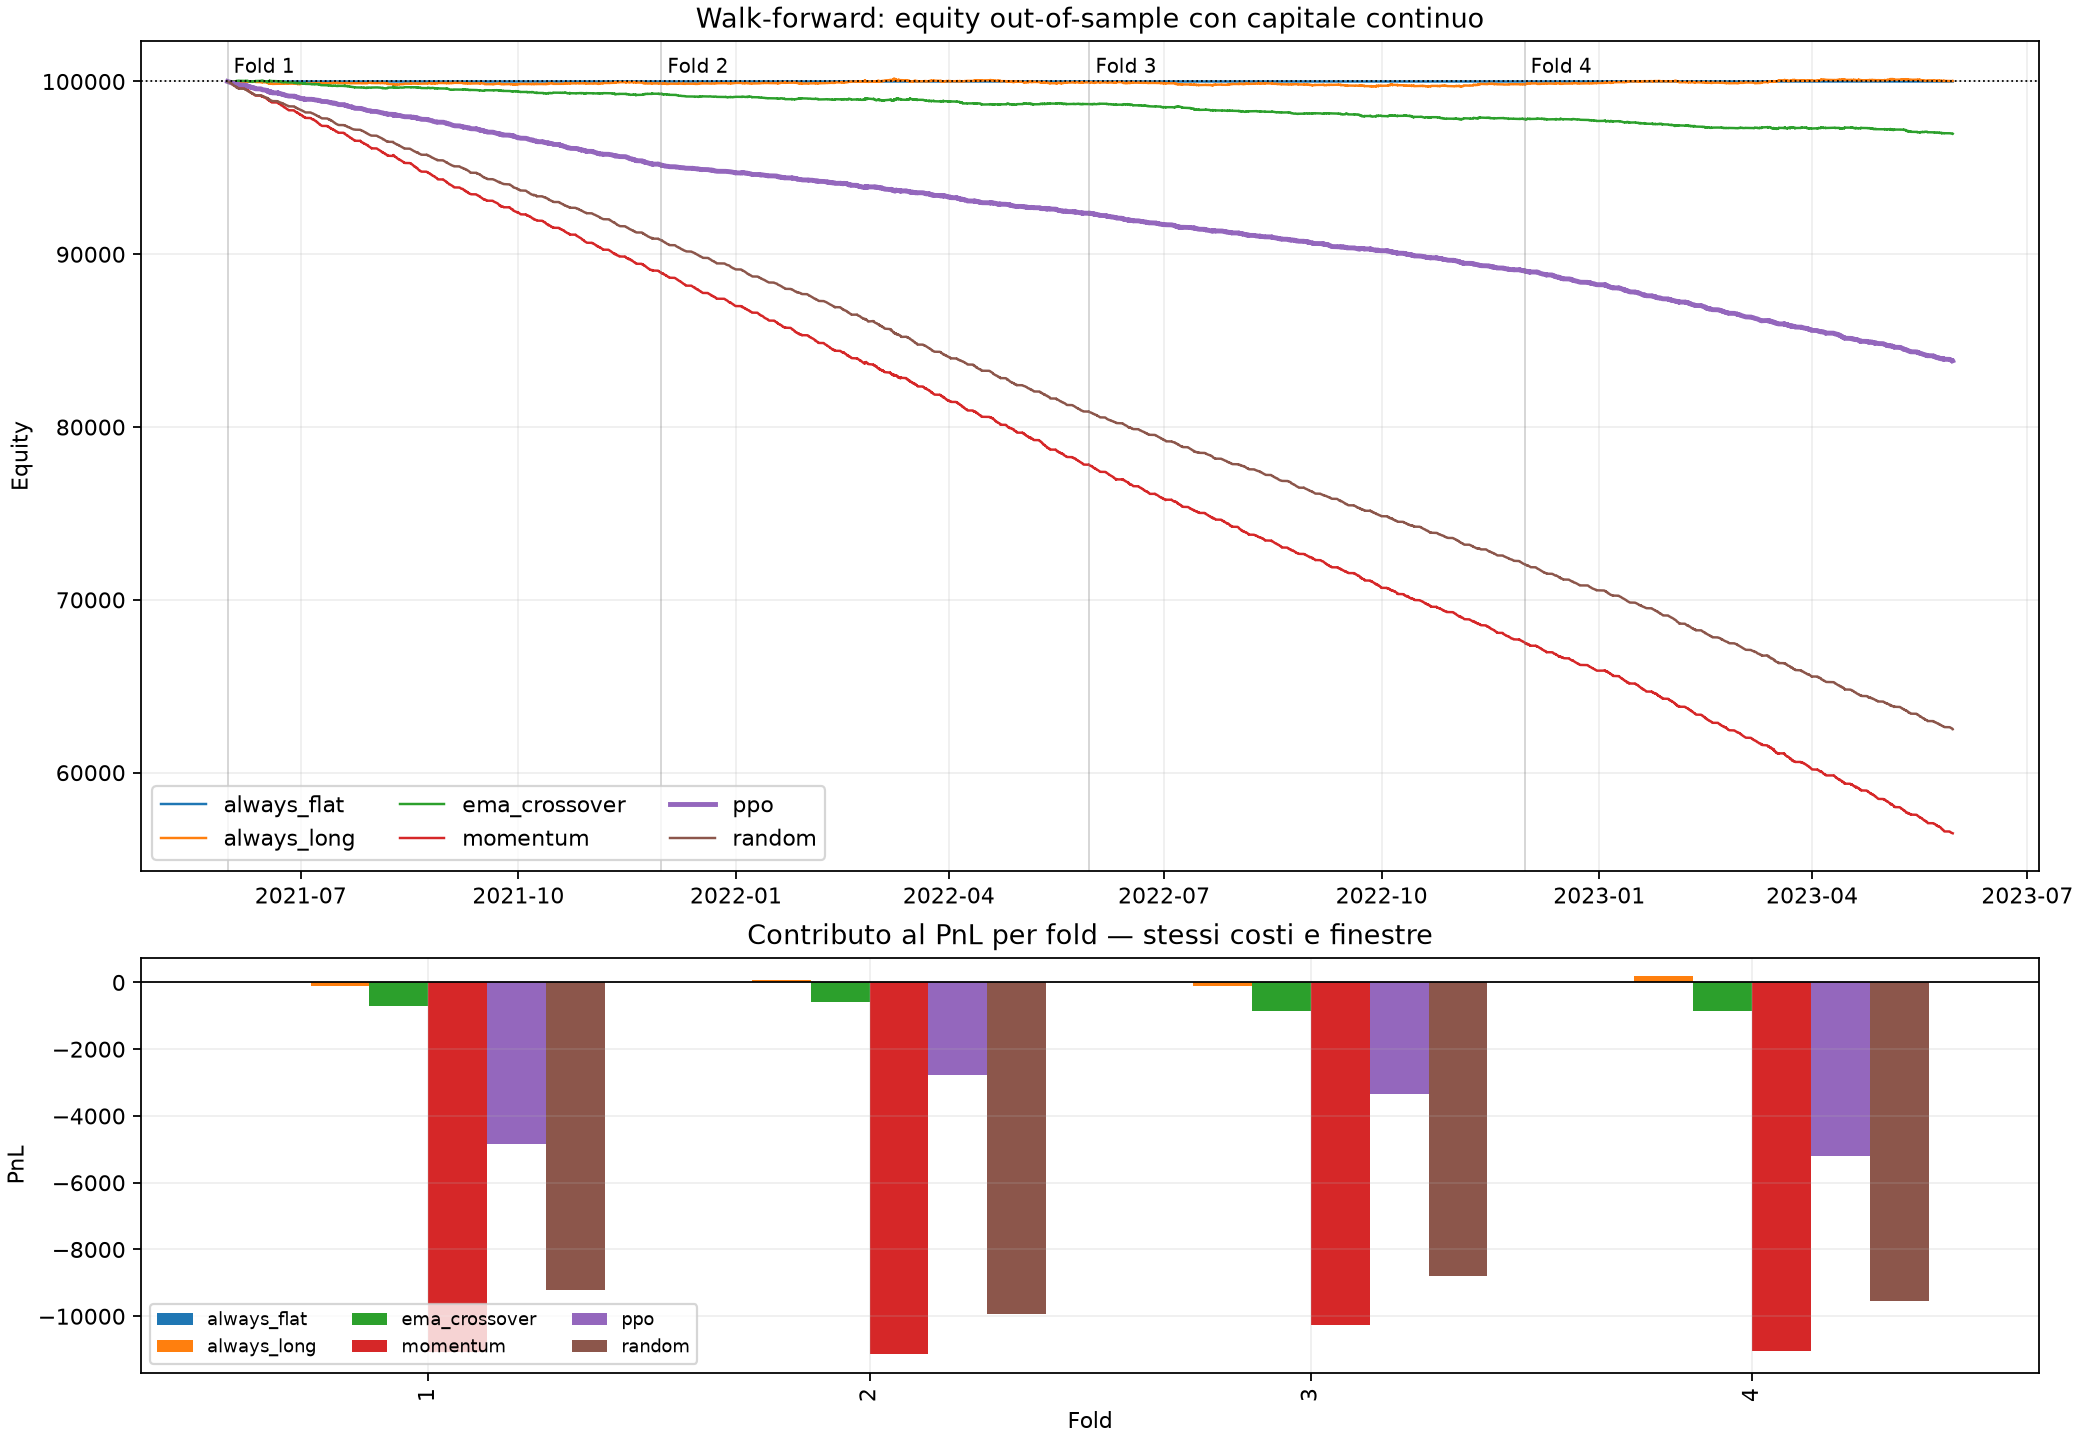

,initial_equity,final_equity,pnl,total_return,max_drawdown,orders,explicit_costs
strategy,,,,,,,
ppo,100000.000000,"83,839.11","-16,160.89",-16.16%,-16.16%,14902,11412.502039
always_flat,100000.000000,"100,000.00",0.00,0.00%,0.00%,0,0.000000
always_long,100000.000000,"100,029.92",29.92,0.03%,-0.45%,8,5.135879
random,100000.000000,"62,516.91","-37,483.09",-37.48%,-37.48%,30865,26313.253861
momentum,100000.000000,"56,490.79","-43,509.21",-43.51%,-43.51%,23937,30385.464666
ema_crossover,100000.000000,"96,978.53","-3,021.47",-3.02%,-3.07%,1649,2103.075051


In [3]:
display(Image(filename=str(REPORT_DIR / "walk_forward.png")))
aggregate = metrics[metrics["scope"] == "aggregate"].set_index("strategy")
display(aggregate[["initial_equity", "final_equity", "pnl", "total_return", "max_drawdown", "orders", "explicit_costs"]].style.format({"total_return":"{:.2%}", "max_drawdown":"{:.2%}", "pnl":"{:,.2f}", "final_equity":"{:,.2f}"}))
for strategy, frame in equity.groupby("strategy"):
    assert frame["timestamp"].is_monotonic_increasing and not frame["timestamp"].duplicated().any()
    initial = summary["oos_starting_capital"]
    previous = frame["equity"].shift(1).fillna(initial)
    assert ((frame["equity"] / previous - 1 - frame["net_return"]).abs() < 1e-12).all()


## Dipendenza da un singolo fold

Il criterio dichiarato prima del training richiede PnL OOS totale positivo, almeno metà dei fold positivi, nessun fold oltre il 50% della somma dei PnL positivi e totale ancora positivo escludendo il contributo di ciascun fold.

Questa esclusione è un'analisi di attribuzione sui trade registrati: non simula nuovamente la policy con un capitale differente. Un risultato complessivamente negativo viene indicato esplicitamente come `non_positive_oos`, senza presentarlo come un successo di robustezza.


In [4]:
fold_metrics = metrics[metrics["scope"] == "fold"]
display(fold_metrics.pivot(index="fold", columns="strategy", values="pnl").style.format("{:,.2f}"))
assessment = summary["assessment"]["ppo"]
display(pd.Series(assessment, name="Criterio PPO"))
if assessment["completion_passed"]:
    display(Markdown("**Criterio preliminare superato:** il PnL positivo non dipende da un unico fold secondo le soglie dichiarate. Non è una prova indipendente di redditività futura."))
else:
    display(Markdown(f"**Criterio non superato: `{assessment['status']}`.** La pipeline walk-forward è stata eseguita, ma non fornisce evidenza di un risultato positivo robusto ai fold."))


strategy,always_flat,always_long,ema_crossover,momentum,ppo,random
fold,,,,,,
1,0.00,-112.92,-719.31,"-11,078.85","-4,839.99","-9,198.98"
2,0.00,61.48,-592.12,"-11,121.14","-2,784.71","-9,931.60"
3,0.00,-99.04,-855.43,"-10,266.16","-3,333.79","-8,807.04"
4,0.00,180.40,-854.61,"-11,043.07","-5,202.41","-9,545.47"


total_pnl                                                                  -16160.890992
positive_folds                                                                         0
max_positive_pnl_share                                                              None
pnl_excluding_each_fold_attribution    [-11320.902870788981, -13376.185480103726, -12...
pnl_excluding_best_fold_attribution                                         -13376.18548
completion_passed                                                                  False
status                                                                  non_positive_oos
criteria                               {'max_positive_pnl_share': 0.5, 'min_positive_...
note                                   Leave-one-out is PnL attribution on recorded t...
Name: Criterio PPO, dtype: object

**Criterio non superato: `non_positive_oos`.** La pipeline walk-forward è stata eseguita, ma non fornisce evidenza di un risultato positivo robusto ai fold.

## Riproduzione e artefatti

```text
python scripts/train_walk_forward.py --run-id nuovo_walk_forward --workers 4
```

I parametri sono in `walk_forward` nel file di configurazione. Si possono scegliere 3–5 fold con `--folds` e un budget diverso con `--timesteps`. Un identificativo esistente viene rifiutato. Ogni esperimento conserva manifest, scaler per fold, hash dei sorgenti/dati, snapshot del codice, modelli e log. Le dipendenze del notebook sono in `requirements-notebook.txt`.

I report principali richiesti sono `reports/walk_forward_metrics.csv`, `reports/walk_forward_equity.csv` e `reports/figures/walk_forward.png`; una copia immutata dei risultati di questo esperimento resta nella directory indicata da `RUN_ID`.

Il disegno delle finestre OOS concatenate è coerente con il [repository di riferimento](https://github.com/ZiadFrancis/Reinforcement_Trading_Part_2/blob/main/README.md), adattato al motore di questo progetto. Questo notebook non avvia training né seleziona modelli: legge e verifica gli artefatti già prodotti.
